## Temporal Evolution of Active Regions 
**We have taken fits files, 1 each per day from 7 May 2026 to 12 May 2026 at around the time 07:09:21 AM, which is the time of image for which we performed preprocessing in part 1. The pipeline that we created in part 1 of the project is applied here with some necessary changes so that new files could be preprocessed properly. The preprocessing includes: flat-field correction, normalization, solar disk masking and applying morphological operations to remove on disk vertical and horizontal patches and to minimise the off-disk distortion.**

**Necessary imports-**

In [1]:
import os
import sys
sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from astropy.io import fits
import sunpy.map 

from suitcolormap import suit_cmap, suit_norm
from scipy.ndimage import uniform_filter
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.measure import regionprops
from sunpy.net import attrs as a
from sunpy.net import Fido
from skimage import measure
import astropy.units as u
from sunpy.coordinates import HeliographicStonyhurst
import glob
import matplotlib.dates as mdates
from datetime import datetime, timedelta

In [2]:
fits_files = sorted(glob.glob(r'..\Data\Raw\*.fits'), key=lambda f: os.path.basename(f).split('_')[5])  # arranging them in date-wise order
print(fits_files)
area_of_ARR14436_list = []
cmap = suit_cmap('NB03')

['..\\Data\\Raw\\SUT_T26_0650_002123_Lev1.0_2026-05-07T07.09.17.939_08B2NB03.fits', '..\\Data\\Raw\\SUT_T26_0648_002127_Lev1.0_2026-05-08T07.08.31.102_08B2NB03.fits', '..\\Data\\Raw\\SUT_T26_0649_002132_Lev1.0_2026-05-09T07.09.21.400_08B2NB03.fits', '..\\Data\\Raw\\SUT_T26_0651_002137_Lev1.0_2026-05-10T07.09.13.937_08B2NB03.fits', '..\\Data\\Raw\\SUT_T26_0652_002142_Lev1.0_2026-05-11T07.09.44.108_08B2NB03.fits', '..\\Data\\Raw\\SUT_T26_0653_002147_Lev1.0_2026-05-12T07.08.58.757_08B2NB03.fits']


Creating a list that will store of the area of the deired active region AR14436-

In [3]:
area_of_ARR14436_list=[]

**Applying the loop:**

In [4]:
for fits_file in fits_files:
    smap = sunpy.map.Map(fits_file)
    arr_2d = smap.data
    arr_2d[arr_2d<0] = 0       # As mentioned before, negative values have no physical significance.
    flat_field = uniform_filter(arr_2d, size=100)    # This is the value of flat-field calculated directly from the data we have.
    '''We have selected size=100 as it not compromising the spatial details of detector and also gives us a valid enough flat field to work with.'''
    # Applying correction:
    flat_field[flat_field<1]=1   # This is being done to prevent the division of arr_2d from 0 as flat_field contains many 0 values.
    arr_ffc = arr_2d/flat_field * np.median(flat_field[flat_field>1]) 

    #Normalization: 
    P1 = np.percentile(arr_ffc, 1)     # 0
    P99 = np.percentile(arr_ffc, 99)   #4658.8745
    arr_normalized = (arr_ffc-P1)/(P99-P1)  # Normalized array.
    arr_normalized = np.clip(arr_normalized,0,1)  # so that all values stay between 0 and 1

    #Masking: 
    x = np.arange(0, 2048)  # Creating 2 lists having values from 0 to 2047 for locating every pixel on the image as its resolution is 2048*2048.
    y = np.arange(0, 2048)
    X, Y = np.meshgrid(x, y)
    radius = 680             # The radius has been tightened further to minimize off-disk distortion from all the images. 
    x_center = 1320
    y_center = 650
    distance = np.sqrt((X-x_center)**2+(Y-y_center)**2)
    mask = (distance<=radius)    # mask is a 2048*2048 boolean array.

    arr_2d_masked = arr_normalized.copy()  
    arr_2d_masked[~mask] = 0 # Unmasked values of arr_2d_masked being given the value of 0.
    
    #Otsu Thresholding: 
    sun_pixels_only = arr_2d_masked[mask]
    sun_pixels_filtered = sun_pixels_only[sun_pixels_only>0.1]  

    threshold_value = threshold_otsu(sun_pixels_filtered)
    print(f'Otsu threshold value = {threshold_value}')  
    active_region_mask = (arr_2d_masked>threshold_value) & mask   # Creating an array which fulfils the Otsu threshold condition and is masked

    # Morphological Operations: 
    
    labeled = label(active_region_mask)
    labeled_regions = regionprops(labeled)

    max_threshold_area = 10000        # This area has been taken to remove solar limb without disturbing any other features.
    bad_labels = []
    for i in labeled_regions:
        if i.area >= max_threshold_area:
            bad_labels.append(i.label)

    updated_labels = np.isin(labeled, bad_labels)
    solar_limb_removed = (active_region_mask) & (~updated_labels)

    # Removing off-disk artifact:
    off_disk_masked = np.zeros(active_region_mask.shape, dtype=bool)
    off_disk_masked[1290:1400, 1010:1150] = True
    off_disk_removed = (solar_limb_removed) & (~off_disk_masked)
    
    # Validation:
    date_str = os.path.basename(fits_file).split('_')[5]  # e.g. '2026-05-09T07.09.21.400'
    date_only = date_str.split('T')[0]  # e.g. '2026-05-09'
    tstart = f'{date_only} 01:00:00'
    tend = f'{date_only} 23:00:00'  
    event_type = 'AR'    # Active Regions
    result = Fido.search(a.Time(tstart,tend), a.hek.EventType(event_type))

    # Columns of Interest: hgs_coord and ar_noaanum

    from skimage import measure
    # We are trying to convert image pixels to Stonyhurst coordinates.
    cleaned_labeled = label(off_disk_removed)
    regions = measure.regionprops(cleaned_labeled)
    # NOTE: here output is in (row,col) format, pixel_to_world uses (col,row) format.

    suit_map = smap
    verified_regions = []
    if 'ar_noaanum' not in result[0].columns:
        area_of_ARR14436_list.append(None)
        print(f'No AR data from HEK for {date_only}')
        continue
    noaa_catalog = result[0][result[0]['ar_noaanum'].filled(0) != 0]
    # Get AR14436's position from HEK
    ar14436_hek = noaa_catalog[noaa_catalog['ar_noaanum'].filled(0) == 14436]

    ar14436_label = []
    if len(ar14436_hek) > 0:
        ar14436_hgs = ar14436_hek['hgs_coord'][0]
        for i in regions:
            x, y = i.centroid
            hpc_coord = suit_map.pixel_to_world(y * u.pixel, x * u.pixel)   # Converting pixel coordinates to hpc.
            hgs_coord = hpc_coord.transform_to(HeliographicStonyhurst)      # converting hgc to hgs
            sep = hgs_coord.separation(ar14436_hgs)
            if sep <= 5 * u.deg:                                          # validation step
                ar14436_label.append(i.label)

# Printing labels found in each iteration along with the area of ARR14336 and appending the list that contains the area-
    print(f'AR14436 labels found: {ar14436_label}')
    if ar14436_label:
        total_area = 0
        for region in regions:
            if region.label in ar14436_label:
                total_area += region.area
        area_of_ARR14436_list.append(total_area)
        print(f'AR14436 area for {date_only}: {total_area} pixels')
    else:
        print(f'AR14436 not detected on {date_only}')
        area_of_ARR14436_list.append(None)

Otsu threshold value = 0.5377017855644226
AR14436 labels found: []
AR14436 not detected on 2026-05-07
Otsu threshold value = 0.5763934254646301


2026-08-04 16:37:20 - astropy - WARNING: NonRotationTransformationWarning: transforming other coordinates from <HeliographicStonyhurst Frame (obstime=2026-05-08T13:12:00.000, rsun=695700.0 km)> to <HeliographicStonyhurst Frame (obstime=2026-05-08T07:08:31.103, rsun=695700.0 km)>. Angular separation can depend on the direction of the transformation.
2026-08-04 16:37:58 - sunpy - WARNING: SunpyUserWarning: The conversion of these 2D helioprojective coordinates to 3D is all NaNs because off-disk coordinates need an additional assumption to be mapped to calculate distance from the observer. Consider using the context manager `SphericalScreen()`.


AR14436 labels found: []
AR14436 not detected on 2026-05-08
Otsu threshold value = 0.5341979265213013


2026-08-04 16:39:51 - astropy - WARNING: NonRotationTransformationWarning: transforming other coordinates from <HeliographicStonyhurst Frame (obstime=2026-05-09T00:00:00.000, rsun=695700.0 km)> to <HeliographicStonyhurst Frame (obstime=2026-05-09T07:09:21.400, rsun=695700.0 km)>. Angular separation can depend on the direction of the transformation.
2026-08-04 16:40:20 - sunpy - WARNING: SunpyUserWarning: The conversion of these 2D helioprojective coordinates to 3D is all NaNs because off-disk coordinates need an additional assumption to be mapped to calculate distance from the observer. Consider using the context manager `SphericalScreen()`.


AR14436 labels found: []
AR14436 not detected on 2026-05-09
Otsu threshold value = 0.5412179827690125


...

AR14436 labels found: [4394, 4652, 4657]
AR14436 area for 2026-05-10: 4758.0 pixels
Otsu threshold value = 0.5764094591140747


2026-08-04 16:44:27 - astropy - WARNING: NonRotationTransformationWarning: transforming other coordinates from <HeliographicStonyhurst Frame (obstime=2026-05-11T00:00:00.000, rsun=695700.0 km)> to <HeliographicStonyhurst Frame (obstime=2026-05-11T07:09:44.108, rsun=695700.0 km)>. Angular separation can depend on the direction of the transformation.
2026-08-04 16:44:52 - sunpy - WARNING: SunpyUserWarning: The conversion of these 2D helioprojective coordinates to 3D is all NaNs because off-disk coordinates need an additional assumption to be mapped to calculate distance from the observer. Consider using the context manager `SphericalScreen()`.


AR14436 labels found: [3460, 3578, 3582]
AR14436 area for 2026-05-11: 6047.0 pixels
Otsu threshold value = 0.5271567106246948


2026-08-04 16:46:20 - astropy - WARNING: NonRotationTransformationWarning: transforming other coordinates from <HeliographicStonyhurst Frame (obstime=2026-05-12T00:00:00.000, rsun=695700.0 km)> to <HeliographicStonyhurst Frame (obstime=2026-05-12T07:08:58.757, rsun=695700.0 km)>. Angular separation can depend on the direction of the transformation.
2026-08-04 16:46:50 - sunpy - WARNING: SunpyUserWarning: The conversion of these 2D helioprojective coordinates to 3D is all NaNs because off-disk coordinates need an additional assumption to be mapped to calculate distance from the observer. Consider using the context manager `SphericalScreen()`.


AR14436 labels found: [3406]
AR14436 area for 2026-05-12: 6483.0 pixels


**Plotting-**

In [5]:
dates = [os.path.basename(f).split('_')[5].split('T')[0] for f in fits_files]  # x-axis will be having dates
print(dates)
print(area_of_ARR14436_list) # y-axis will have area of AR14436 on respective dates

['2026-05-07', '2026-05-08', '2026-05-09', '2026-05-10', '2026-05-11', '2026-05-12']
[None, None, None, np.float64(4758.0), np.float64(6047.0), np.float64(6483.0)]


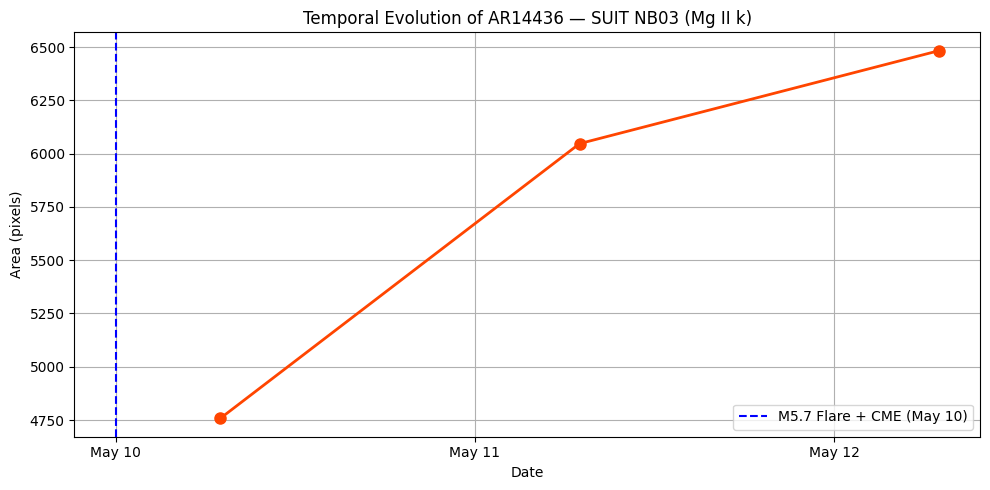

In [6]:
# Plotting:
dates_dt = [datetime.strptime(d, '%Y-%m-%d') + timedelta(hours=7) for d in dates]
areas = [a if a is not None else float('nan') for a in area_of_ARR14436_list]

plt.figure(figsize=(10, 5))
plt.plot(dates_dt, areas, marker='o', color='orangered', linewidth=2, markersize=8)
plt.axvline(datetime(2026, 5, 10), color='blue', linestyle='--', label='M5.7 Flare + CME (May 10)')
plt.xlabel('Date')
plt.ylabel('Area (pixels)')
plt.title('Temporal Evolution of AR14436 — SUIT NB03 (Mg II k)')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.tight_layout()
plt.savefig(r'..\Outputs\Figures\Fig_Part2A_Temporal_Evolution.png', dpi=150, bbox_inches='tight')
plt.show()